In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

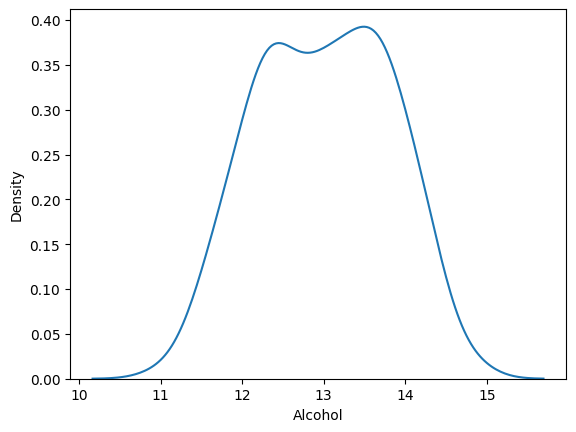

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

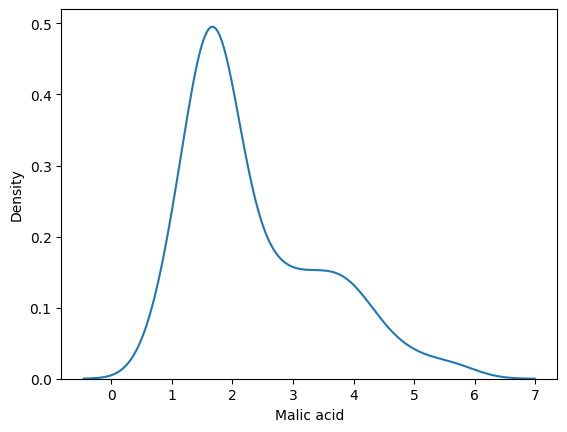

In [5]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

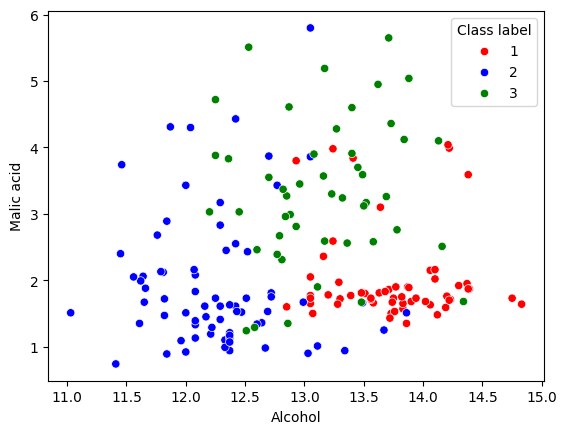

In [6]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

# MinMaxScaler

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [10]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [11]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


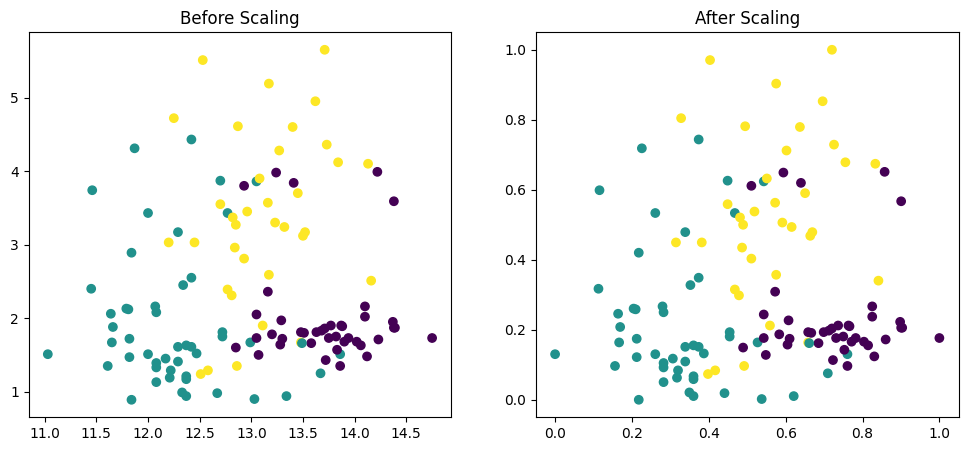

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

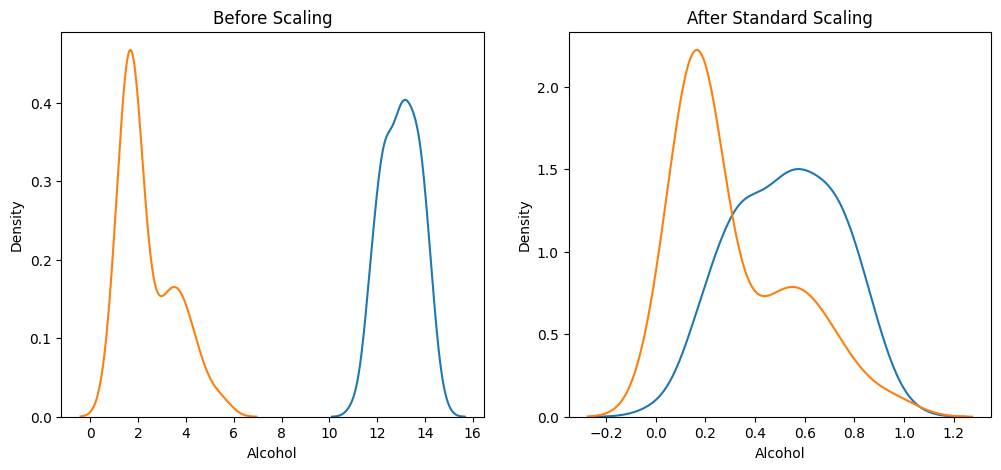

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

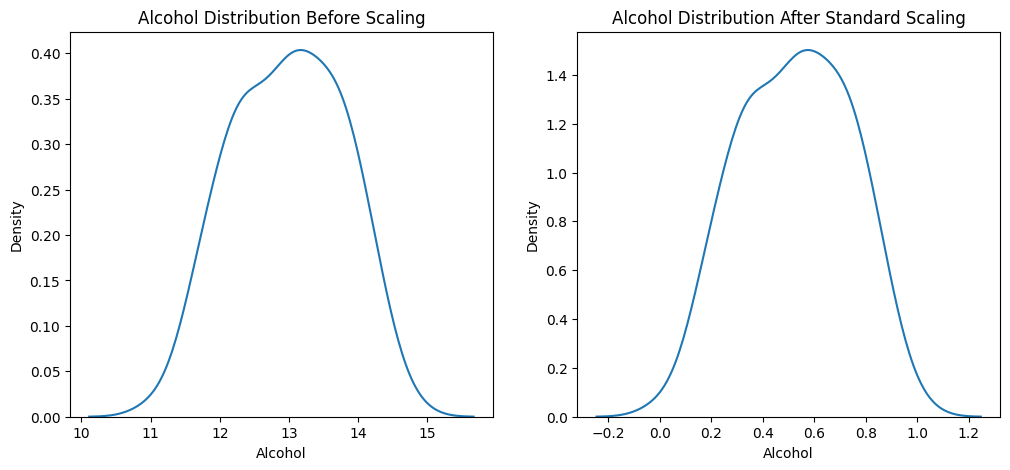

In [14]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

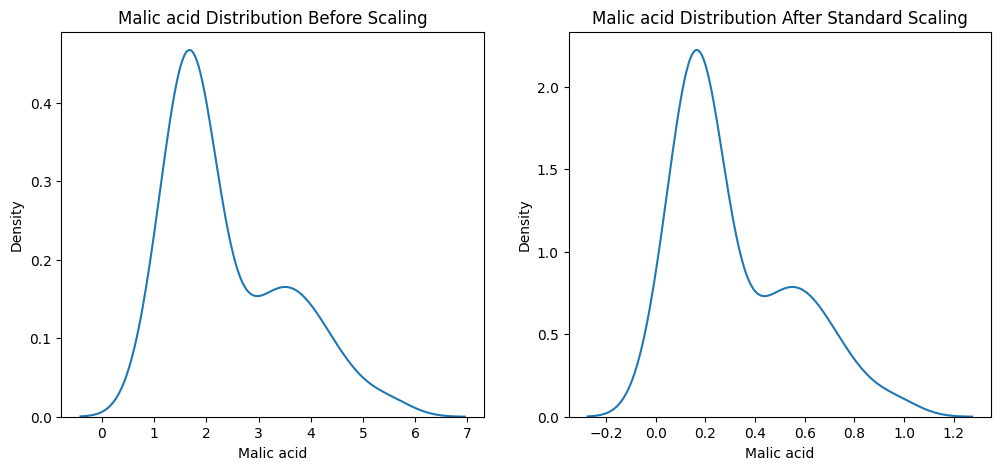

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

# Robust Scaling

In [16]:
from sklearn.preprocessing import RobustScaler

In [17]:
df = pd.read_csv('wine_data.csv', header=None)

## Add Column Names!

In [18]:
columns = [
    'Class','Alcohol','Malic_Acid','Ash','Alcalinity_of_Ash',
    'Magnesium','Total_Phenols','Flavanoids',
    'Nonflavanoid_Phenols','Proanthocyanins',
    'Color_Intensity','Hue',
    'OD280_OD315','Proline'
]

df.columns = columns

## Add Extreme Outliers

In [19]:
df = pd.concat([
    df,
    pd.DataFrame({
        'Class':[1,1,1],
        'Alcohol':[50,60,70],
        'Malic_Acid':[20,25,30],
        'Ash':[10,12,15],
        'Alcalinity_of_Ash':[80,90,100],
        'Magnesium':[500,700,1000],
        'Total_Phenols':[15,20,25],
        'Flavanoids':[20,25,30],
        'Nonflavanoid_Phenols':[5,6,7],
        'Proanthocyanins':[10,12,15],
        'Color_Intensity':[40,50,60],
        'Hue':[5,6,7],
        'OD280_OD315':[10,12,15],
        'Proline':[5000,7000,10000]
    })
], ignore_index=True)

## Separate Features & Target

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
scaler = RobustScaler()

In [23]:
scaler.fit(X_train)

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [24]:
X_train.shape, X_test.shape

((144, 13), (37, 13))

In [25]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

In [27]:
np.round(X_train.describe())

,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0
mean,14.0,3.0,3.0,21.0,112.0,3.0,2.0,0.0,2.0,6.0,1.0,3.0,877.0
std,7.0,3.0,1.0,11.0,97.0,3.0,3.0,1.0,2.0,7.0,1.0,2.0,1038.0
min,11.0,1.0,1.0,11.0,70.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,278.0
25%,12.0,2.0,2.0,18.0,88.0,2.0,1.0,0.0,1.0,3.0,1.0,2.0,499.0
50%,13.0,2.0,2.0,20.0,98.0,2.0,2.0,0.0,2.0,5.0,1.0,3.0,666.0
75%,14.0,3.0,3.0,22.0,107.0,3.0,3.0,0.0,2.0,6.0,1.0,3.0,996.0
max,70.0,30.0,15.0,100.0,1000.0,25.0,30.0,7.0,15.0,60.0,7.0,15.0,10000.0


In [28]:
X_train_scaled.describe()

,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,144.000000,144.000000,144.000000,144.000000,144.000000,1.440000e+02,1.440000e+02,144.000000,1.440000e+02,1.440000e+02,144.000000,144.000000,144.000000
mean,0.714815,0.583886,0.615977,0.369115,0.761330,3.428699e-01,2.226092e-01,0.769144,3.755399e-01,3.599149e-01,0.251990,0.013724,0.424539
std,5.249151,2.129736,4.335506,2.423372,5.084620,2.475345e+00,2.159355e+00,4.460993,2.356264e+00,2.211850e+00,2.289248,1.259856,2.086038
min,-1.508571,-0.612557,-2.919708,-2.011299,-1.473684,-1.184332e+00,-1.111455e+00,-1.135135,-1.575972e+00,-1.138756e+00,-1.492537,-1.193676,-0.779899
25%,-0.487619,-0.159265,-0.437956,-0.435028,-0.526316,-5.069124e-01,-5.479876e-01,-0.378378,-4.134276e-01,-5.135566e-01,-0.574627,-0.691700,-0.336181
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.012279e-16,1.374768e-16,0.000000,-1.569925e-16,1.422473e-16,0.000000,0.000000,0.000000
75%,0.512381,0.840735,0.562044,0.564972,0.473684,4.930876e-01,4.520124e-01,0.621622,5.865724e-01,4.864434e-01,0.425373,0.308300,0.663819
max,43.420952,17.218989,36.905109,18.192090,47.473684,2.095392e+01,1.725387e+01,36.000000,1.903180e+01,1.759171e+01,17.970149,9.660079,18.761809


<Axes: >

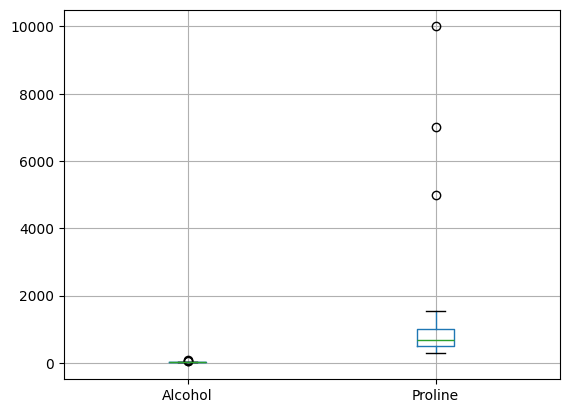

In [29]:
X_train[['Alcohol','Proline']].boxplot()


<Axes: >

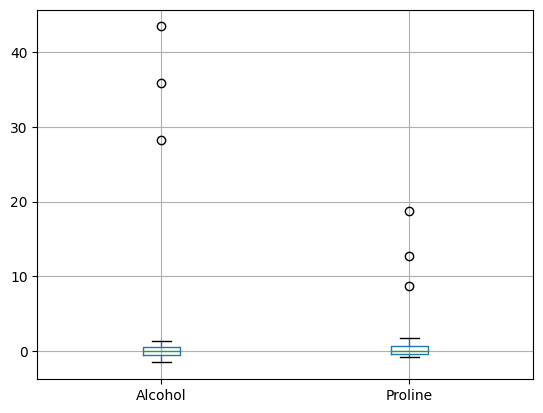

In [30]:
X_train_scaled[['Alcohol','Proline']].boxplot()

In [31]:
X_train_scaled.median()

Alcohol                 0.000000e+00
Malic_Acid              0.000000e+00
Ash                     0.000000e+00
Alcalinity_of_Ash       0.000000e+00
Magnesium               0.000000e+00
Total_Phenols           2.046974e-16
Flavanoids              1.374768e-16
Nonflavanoid_Phenols    0.000000e+00
Proanthocyanins        -1.569925e-16
Color_Intensity         1.422473e-16
Hue                     0.000000e+00
OD280_OD315             0.000000e+00
Proline                 0.000000e+00
dtype: float64

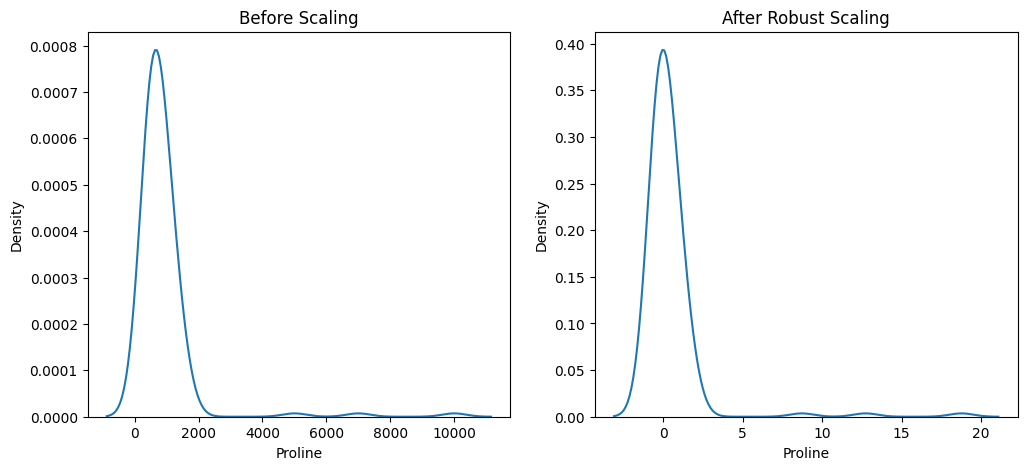

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(X_train['Proline'])
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.kdeplot(X_train_scaled['Proline'])
plt.title("After Robust Scaling")

plt.show()

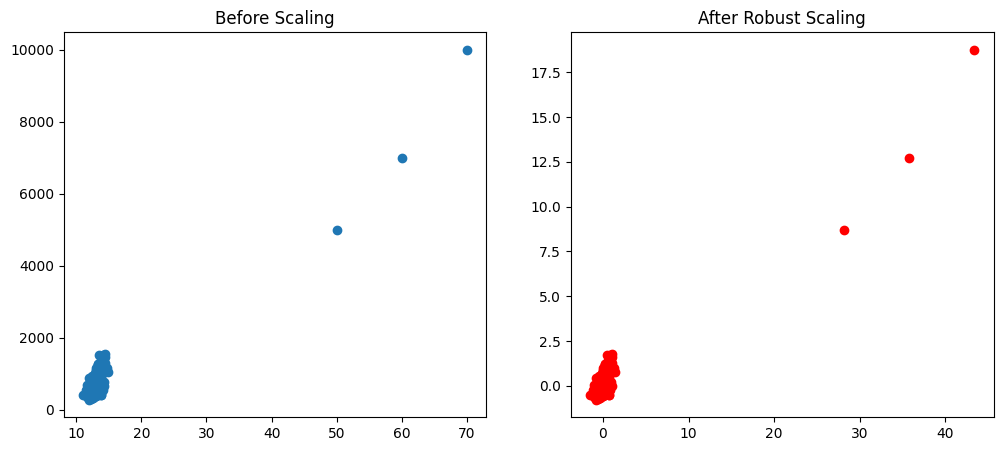

In [33]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Before
ax1.scatter(X_train['Alcohol'], X_train['Proline'])
ax1.set_title("Before Scaling")

# After
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Proline'], color='red')
ax2.set_title("After Robust Scaling")

plt.show()

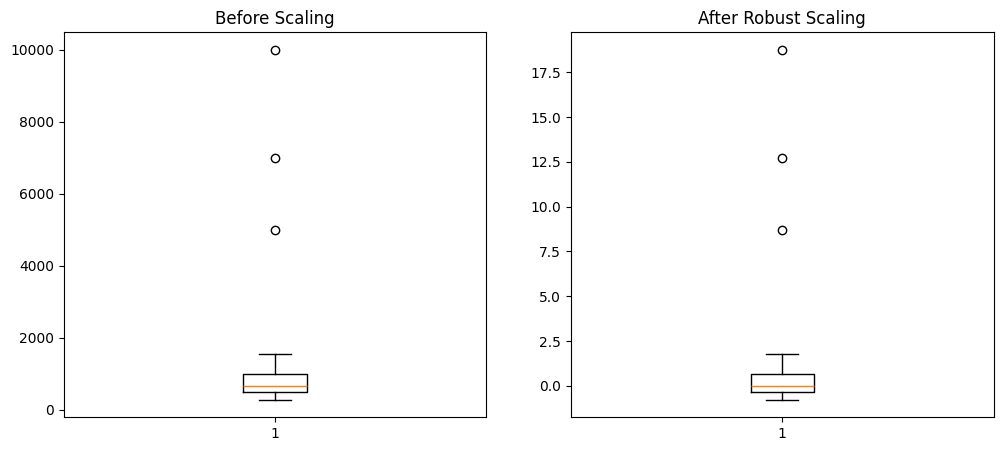

In [34]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Before
ax1.boxplot(X_train['Proline'])
ax1.set_title("Before Scaling")

# After
ax2.boxplot(X_train_scaled['Proline'])
ax2.set_title("After Robust Scaling")

plt.show()